In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json


In [3]:
img_size = 224
batch_size = 32
num_classes = 29  # As per your dataset
epochs_stage1 = 20
epochs_stage2 = 10

model_name = 'mobilenetv2_gemstone_best_model_80_20.h5'
history_file = 'mobilenetv2_gemstone_history_80_20.json'


In [4]:
train_dir = '/content/drive/MyDrive/New_80-20/train'
val_dir = '/content/drive/MyDrive/New_80-20/test'


In [5]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 4176 images belonging to 29 classes.
Found 1044 images belonging to 29 classes.


In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(model_name, monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1857 - loss: 3.0498

131/131 ━━━━━━━━━━━━━━━━━━━━ 1568s 12s/step - accuracy: 0.1869 - loss: 3.0452 - val_accuracy: 0.7462 - val_loss: 1.2782 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6812 - loss: 1.2626

131/131 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.6814 - loss: 1.2616 - val_accuracy: 0.8276 - val_loss: 0.7245 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7989 - loss: 0.7962

131/131 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.7989 - loss: 0.7958 - val_accuracy: 0.8870 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8422 - loss: 0.5912

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9291 - loss: 0.2831 - val_accuracy: 0.9368 - val_loss: 0.2334 - learning_rate: 0.0010
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9319 - loss: 0.2525

131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.9319 - loss: 0.2525 - val_accuracy: 0.9377 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 11/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9376 - loss: 0.2363

131/131 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.9376 - loss: 0.2364 - val_accuracy: 0.9492 - val_loss: 0.2039 - learning_rate: 0.0010
Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9399 - loss: 0.2178 - val_accuracy: 0.9473 - val_loss: 0.1960 - learning_rate: 0.0010
Epoch 13/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9444 - loss: 0.2202

131/131 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9444 - loss: 0.2202 - val_accuracy: 0.9521 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 14/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9483 - loss: 0.2038

131/131 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9483 - loss: 0.2037 - val_accuracy: 0.9550 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 15/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9506 - loss: 0.1791 - val_accuracy: 0.9521 - val_loss: 0.1744 - learning_rate: 0.0010
Epoch 16/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9580 - loss: 0.1720 - val_accuracy: 0.9550 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 17/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9578 - loss: 0.1709
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
131/131 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9578 - loss: 0.1709 - val_accuracy: 0.9521 - val_loss: 0.1570 - learning_rate: 0.0010
Epoch 18/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9616 - loss: 0.1539 - val_accuracy: 0.9550 - val_loss: 0.1553 - learning_rate: 5.0000e-04
Epoch 19/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9658 - loss: 0.1484

In [8]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=SGD(learning_rate=1e-4, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=callbacks
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7617 - loss: 0.8338 - val_accuracy: 0.9492 - val_loss: 0.1802 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9084 - loss: 0.4188 - val_accuracy: 0.9435 - val_loss: 0.1809 - learning_rate: 1.0000e-04
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9107 - loss: 0.3368 - val_accuracy: 0.9454 - val_loss: 0.1724 - learning_rate: 1.0000e-04
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9379 - loss: 0.2594
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
131/131 ━━━━━━━━━━━━━━━━━━━━ 346s 3s/step - accuracy: 0.9378 - loss: 0.2595 - val_accuracy: 0.9492 - val_loss: 0.1631 - learning_rate: 1.0000e-04
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9517 - loss: 0.2164 - val_accuracy: 0.9483 - val_loss: 0.1568 - learning_rate: 5.0000e-05
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.

131/131 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.9503 - loss: 0.2071 - val_accuracy: 0.9559 - val_loss: 0.1510 - learning_rate: 5.0000e-05
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9523 - loss: 0.1931 - val_accuracy: 0.9559 - val_loss: 0.1455 - learning_rate: 5.0000e-05
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9562 - loss: 0.1828

131/131 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.9562 - loss: 0.1828 - val_accuracy: 0.9598 - val_loss: 0.1405 - learning_rate: 5.0000e-05
Epoch 9/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9597 - loss: 0.1662

131/131 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.9597 - loss: 0.1662 - val_accuracy: 0.9626 - val_loss: 0.1369 - learning_rate: 5.0000e-05
Epoch 10/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9614 - loss: 0.1711 - val_accuracy: 0.9617 - val_loss: 0.1344 - learning_rate: 5.0000e-05


In [16]:
total_history = {
    "accuracy": history.history['accuracy'] + fine_tune_history.history['accuracy'],
    "val_accuracy": history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    "loss": history.history['loss'] + fine_tune_history.history['loss'],
    "val_loss": history.history['val_loss'] + fine_tune_history.history['val_loss']
}

with open(history_file, 'w') as f:
    json.dump(total_history, f)

np.save('/content/class_labels_gemstone_80_20.npy', train_generator.class_indices)


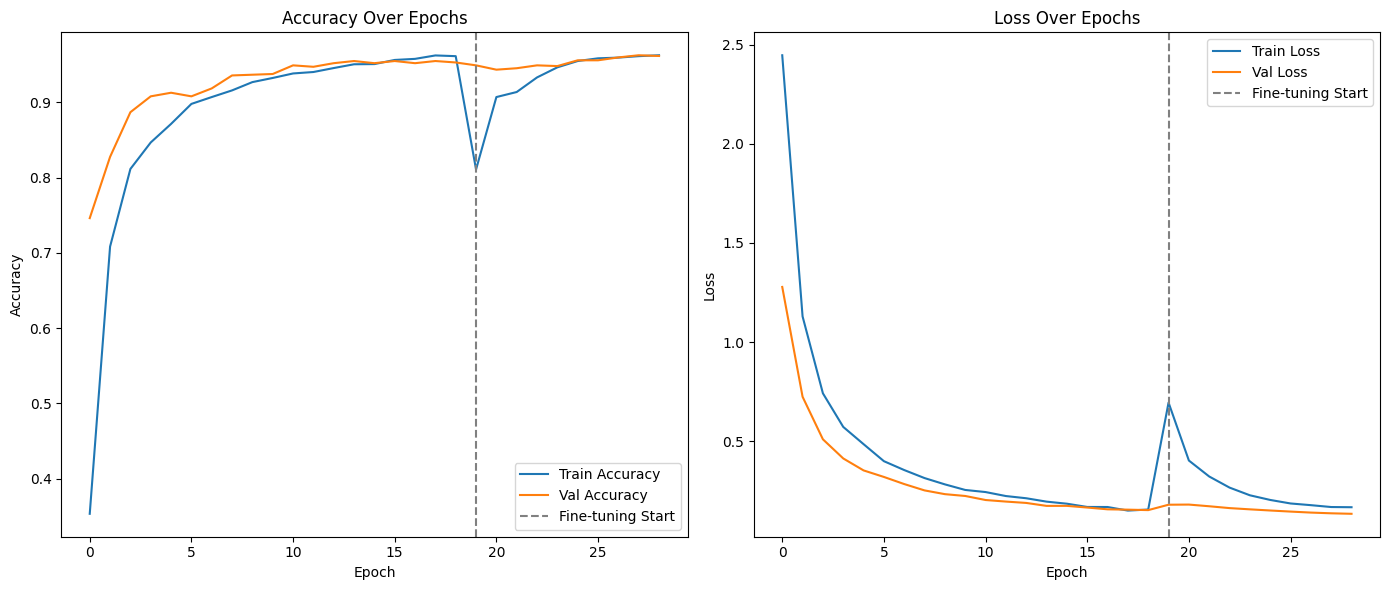

In [10]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(total_history['accuracy'], label='Train Accuracy')
plt.plot(total_history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(total_history['loss'], label='Train Loss')
plt.plot(total_history['val_loss'], label='Val Loss')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9522 - loss: 0.1602

✅ Test Accuracy: 96.26%
✅ Test Loss: 0.1369


33/33 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


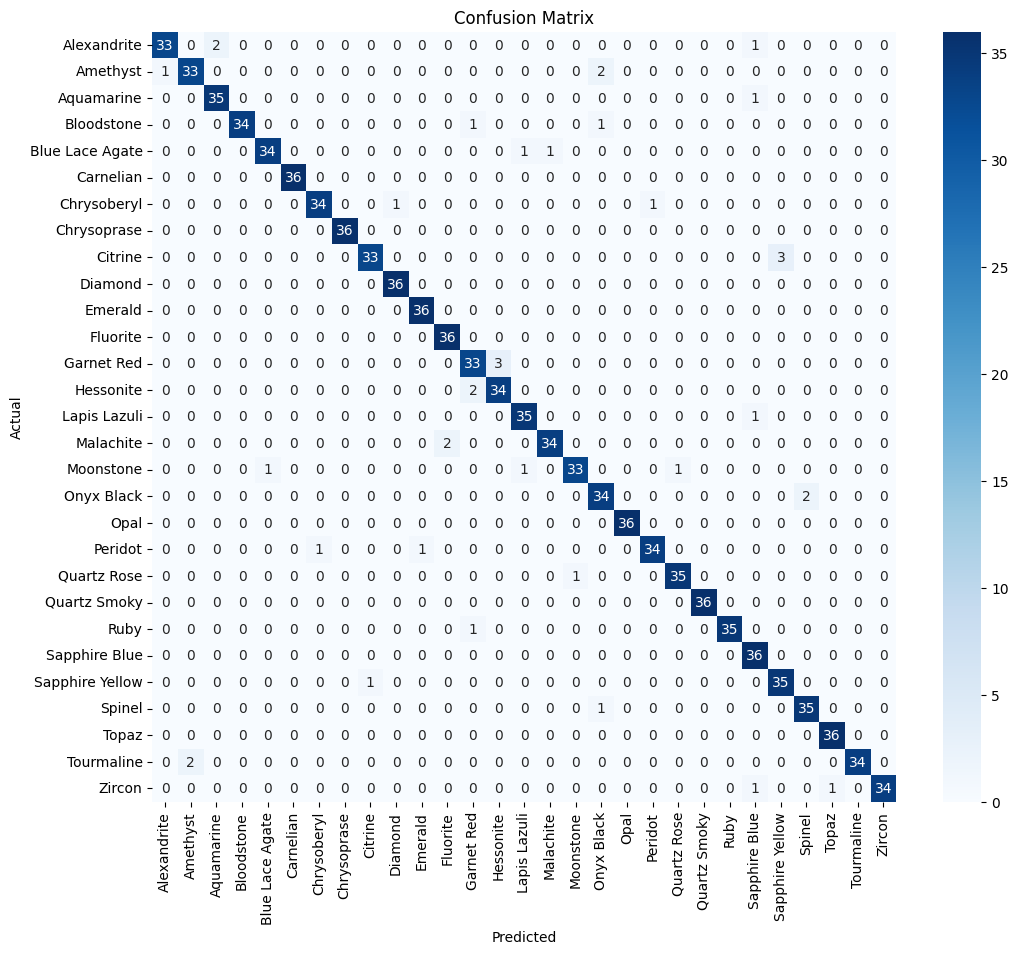

In [12]:
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [17]:
# 🔹 Misclassified Images
filenames = val_generator.filenames
misclassified = []

for i in range(len(y_pred)):
    if y_pred[i] != y_true[i]:
        misclassified.append(f"{filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}")

# Save to file
misclassified_file = "misclassified_images_report_70_30.txt"
with open(misclassified_file, "w") as f:
    f.write("\n".join(misclassified))


In [14]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report (70-30):\n", report)

with open("classification_report_gemstone_70_30.txt", "w") as f:
    f.write(report)



📊 Classification Report (70-30):
                  precision    recall  f1-score   support

    Alexandrite       0.97      0.92      0.94        36
       Amethyst       0.94      0.92      0.93        36
     Aquamarine       0.95      0.97      0.96        36
     Bloodstone       1.00      0.94      0.97        36
Blue Lace Agate       0.97      0.94      0.96        36
      Carnelian       1.00      1.00      1.00        36
    Chrysoberyl       0.97      0.94      0.96        36
    Chrysoprase       1.00      1.00      1.00        36
        Citrine       0.97      0.92      0.94        36
        Diamond       0.97      1.00      0.99        36
        Emerald       0.97      1.00      0.99        36
       Fluorite       0.95      1.00      0.97        36
     Garnet Red       0.89      0.92      0.90        36
      Hessonite       0.92      0.94      0.93        36
   Lapis Lazuli       0.95      0.97      0.96        36
      Malachite       0.97      0.94      0.96      

In [15]:
model.save('mobilenetv2_gemstone_classifier_final_70_30.h5')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 6,802,364 (25.95 MB)

 Trainable params: 3,202,909 (12.22 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,202,911 (12.22 MB)

In [18]:
additional_epochs = 20

fine_tune_history_more = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=additional_epochs,
    callbacks=callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9611 - loss: 0.1787 - val_accuracy: 0.9626 - val_loss: 0.1341 - learning_rate: 5.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.9657 - loss: 0.1577 - val_accuracy: 0.9617 - val_loss: 0.1317 - learning_rate: 5.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9632 - loss: 0.1465 - val_accuracy: 0.9607 - val_loss: 0.1291 - learning_rate: 5.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9715 - loss: 0.1359

131/131 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.9715 - loss: 0.1359 - val_accuracy: 0.9655 - val_loss: 0.1264 - learning_rate: 5.0000e-05
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9702 - loss: 0.1414 - val_accuracy: 0.9655 - val_loss: 0.1246 - learning_rate: 5.0000e-05
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9738 - loss: 0.1336 - val_accuracy: 0.9646 - val_loss: 0.1229 - learning_rate: 5.0000e-05
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9718 - loss: 0.1289
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
131/131 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9718 - loss: 0.1289 - val_accuracy: 0.9655 - val_loss: 0.1205 - learning_rate: 5.0000e-05
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9771 - loss: 0.1058

131/131 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9771 - loss: 0.1059 - val_accuracy: 0.9665 - val_loss: 0.1197 - learning_rate: 2.5000e-05
Epoch 9/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9756 - loss: 0.1145 - val_accuracy: 0.9655 - val_loss: 0.1191 - learning_rate: 2.5000e-05
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9749 - loss: 0.1129 - val_accuracy: 0.9655 - val_loss: 0.1178 - learning_rate: 2.5000e-05
Epoch 11/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9753 - loss: 0.1110
Epoch 11: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
131/131 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9753 - loss: 0.1110 - val_accuracy: 0.9655 - val_loss: 0.1164 - learning_rate: 2.5000e-05
Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9741 - loss: 0.1153

KeyboardInterrupt: 

In [21]:
import json

# Load existing history
with open('/content/mobilenetv2_gemstone_history_80_20.json', 'r') as f:
    total_history = json.load(f)

# Add new fine-tuning history
total_history['accuracy'] += fine_tune_history_more.history['accuracy']
total_history['val_accuracy'] += fine_tune_history_more.history['val_accuracy']
total_history['loss'] += fine_tune_history_more.history['loss']
total_history['val_loss'] += fine_tune_history_more.history['val_loss']

# Save updated history
with open('/content/drive/MyDrive/.../mobilenetv2_gemstone_history_80_20.json', 'w') as f:
    json.dump(total_history, f)


NameError: name 'fine_tune_history_more' is not defined

In [22]:
import json

# Load existing history
with open('/content/mobilenetv2_gemstone_history_80_20.json', 'r') as f:
    total_history = json.load(f)

# Add new fine-tuning partial history (12 epochs)
total_history['accuracy'] += fine_tune_history_more.history['accuracy']
total_history['val_accuracy'] += fine_tune_history_more.history['val_accuracy']
total_history['loss'] += fine_tune_history_more.history['loss']
total_history['val_loss'] += fine_tune_history_more.history['val_loss']

# Save updated history back to file
with open('/content/mobilenetv2_gemstone_history_80_20.json', 'w') as f:
    json.dump(total_history, f)


NameError: name 'fine_tune_history_more' is not defined

In [23]:
fine_tune_history_more = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,  # for example, remaining epochs if you stopped at 12 out of 20
    callbacks=callbacks
)


Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.9757 - loss: 0.1032 - val_accuracy: 0.9655 - val_loss: 0.1157 - learning_rate: 1.2500e-05
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9770 - loss: 0.1157 - val_accuracy: 0.9665 - val_loss: 0.1151 - learning_rate: 1.2500e-05
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.9779 - loss: 0.1065 - val_accuracy: 0.9655 - val_loss: 0.1146 - learning_rate: 1.2500e-05
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.9764 - loss: 0.1111 - val_accuracy: 0.9655 - val_loss: 0.1142 - learning_rate: 1.2500e-05
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9790 - loss: 0.1044
Epoch 5: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9790 - loss: 0.1043 - val_accuracy: 0.9665 - val_loss: 0.1138 - learning_rate: 1.2500e-05
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9815 - 

131/131 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9815 - loss: 0.1031 - val_accuracy: 0.9674 - val_loss: 0.1137 - learning_rate: 6.2500e-06
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9804 - loss: 0.0991

131/131 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.9804 - loss: 0.0991 - val_accuracy: 0.9684 - val_loss: 0.1136 - learning_rate: 6.2500e-06
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9777 - loss: 0.1043

131/131 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9777 - loss: 0.1043 - val_accuracy: 0.9693 - val_loss: 0.1135 - learning_rate: 6.2500e-06


In [24]:
import json

# Load existing history
with open('/content/mobilenetv2_gemstone_history_80_20.json', 'r') as f:
    total_history = json.load(f)

# Add new fine-tuning partial history (12 epochs)
total_history['accuracy'] += fine_tune_history_more.history['accuracy']
total_history['val_accuracy'] += fine_tune_history_more.history['val_accuracy']
total_history['loss'] += fine_tune_history_more.history['loss']
total_history['val_loss'] += fine_tune_history_more.history['val_loss']

# Save updated history back to file
with open('/content/mobilenetv2_gemstone_history_80_20.json', 'w') as f:
    json.dump(total_history, f)


In [25]:
model.save('/content/drive/MyDrive/mobilenetv2_gemstone_final.keras')
model.save('/content/drive/MyDrive/mobilenetv2_gemstone_final.h5')



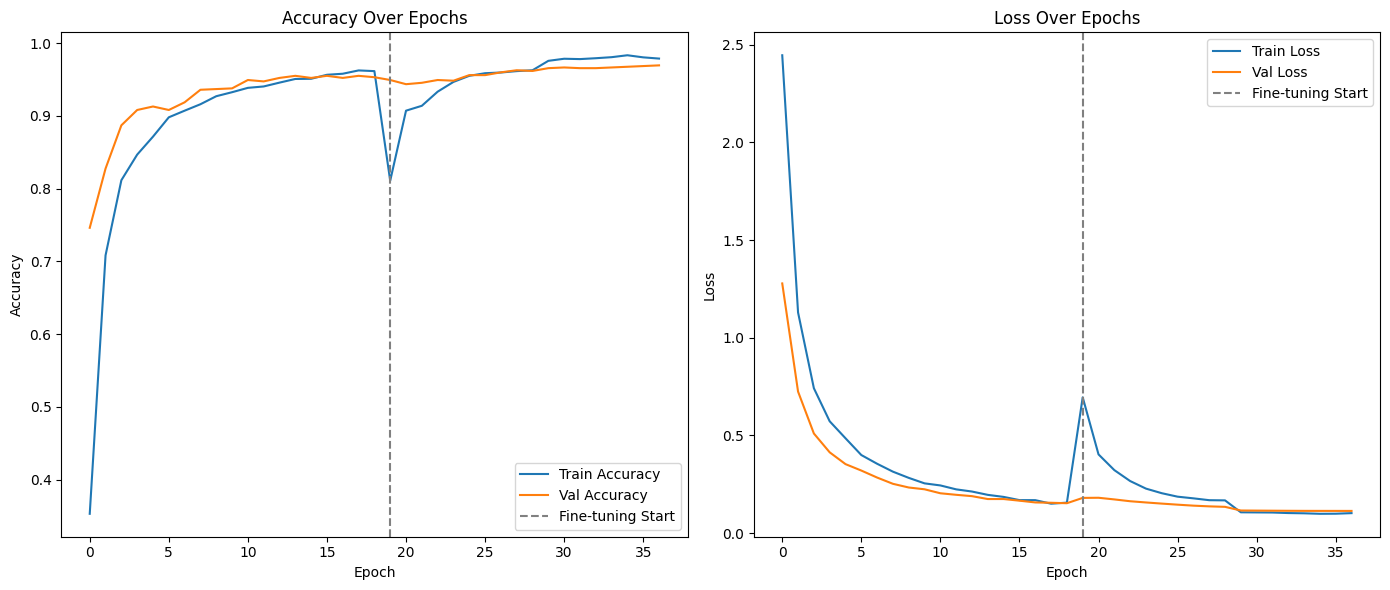

In [26]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(total_history['accuracy'], label='Train Accuracy')
plt.plot(total_history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(total_history['loss'], label='Train Loss')
plt.plot(total_history['val_loss'], label='Val Loss')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9580 - loss: 0.1344

✅ Test Accuracy: 96.93%
✅ Test Loss: 0.1135


33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step


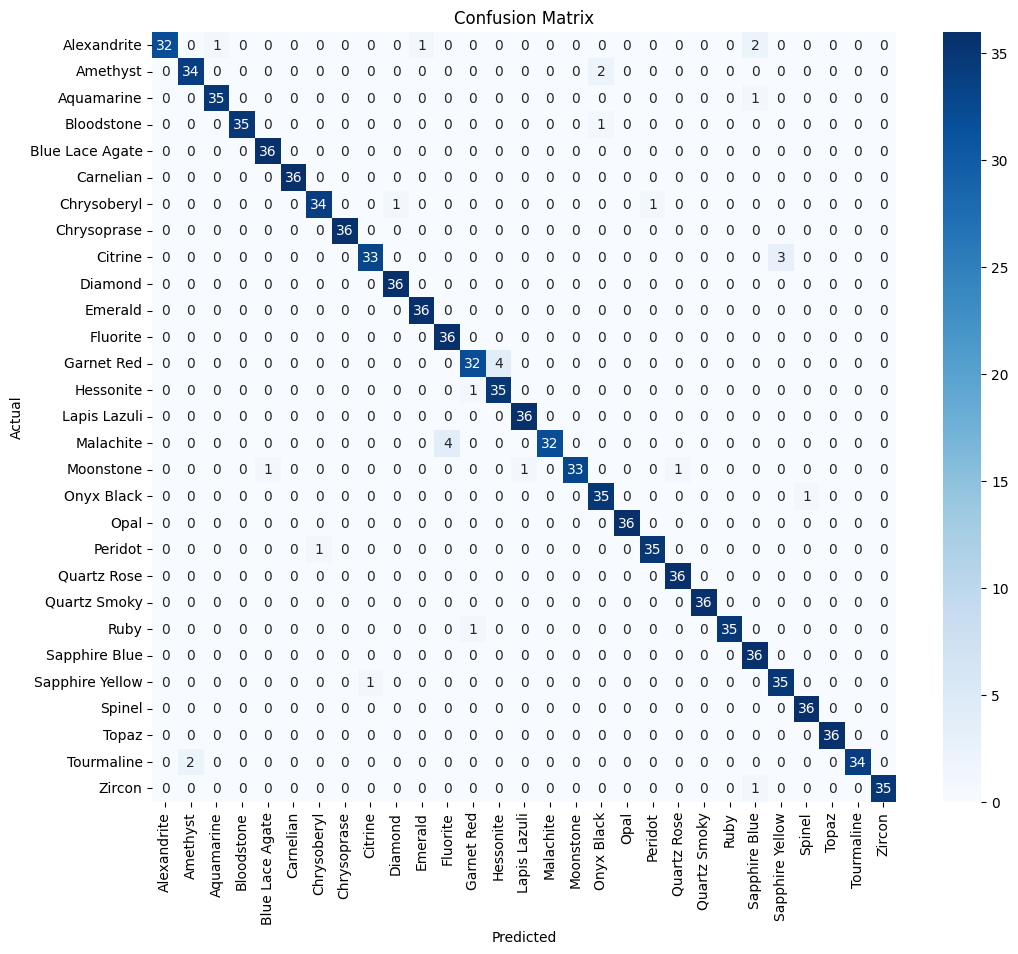

In [28]:
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [32]:
# 🔹 Misclassified Images
filenames = val_generator.filenames
misclassified = []

for i in range(len(y_pred)):
    if y_pred[i] != y_true[i]:
        misclassified.append(f"{filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}")

# Save to file
misclassified_file = "misclassified_images_report_80_20.txt"
with open(misclassified_file, "w") as f:
    f.write("\n".join(misclassified))


In [33]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report (80-20):\n", report)

with open("classification_report_gemstone_80_20.txt", "w") as f:
    f.write(report)



📊 Classification Report (80-20):
                  precision    recall  f1-score   support

    Alexandrite       1.00      0.89      0.94        36
       Amethyst       0.94      0.94      0.94        36
     Aquamarine       0.97      0.97      0.97        36
     Bloodstone       1.00      0.97      0.99        36
Blue Lace Agate       0.97      1.00      0.99        36
      Carnelian       1.00      1.00      1.00        36
    Chrysoberyl       0.97      0.94      0.96        36
    Chrysoprase       1.00      1.00      1.00        36
        Citrine       0.97      0.92      0.94        36
        Diamond       0.97      1.00      0.99        36
        Emerald       0.97      1.00      0.99        36
       Fluorite       0.90      1.00      0.95        36
     Garnet Red       0.94      0.89      0.91        36
      Hessonite       0.90      0.97      0.93        36
   Lapis Lazuli       0.97      1.00      0.99        36
      Malachite       1.00      0.89      0.94      

In [31]:
model.save('mobilenetv2_gemstone_classifier_final_70_30.h5')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 6,802,364 (25.95 MB)

 Trainable params: 3,202,909 (12.22 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,202,911 (12.22 MB)

In [34]:
model.save('/content/drive/MyDrive/mobilenetv2_gemstone_final.keras')
model.save('/content/drive/MyDrive/mobilenetv2_gemstone_final.h5')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 6,802,364 (25.95 MB)

 Trainable params: 3,202,909 (12.22 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,202,911 (12.22 MB)